In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the datasets
df_air = pd.read_csv('Airbnb_Open_Data_Small.csv', low_memory=False)
df_crime = pd.read_csv('NYPD_Crime_Data_Cleaned.csv', low_memory=False)
df_mta = pd.read_csv('MTA_Subway_Stations.csv', low_memory=False)

# 2. Data Cleaning: Price formatting
df_air['price'] = df_air['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
df_air['price'] = pd.to_numeric(df_air['price'], errors='coerce')
df_air = df_air.dropna(subset=['price'])

# 3. Standardization: Borough names
df_air['neighbourhood group'] = df_air['neighbourhood group'].str.upper().str.strip()
df_crime['BORO_NM'] = df_crime['BORO_NM'].str.upper().str.strip()
# Critical Fix for Metro: Standardizing abbreviations before mapping
df_mta['Borough'] = df_mta['Borough'].str.upper().str.strip()

# 4. Feature Engineering: Define Price Categories
def categorize_price(price):
    if price <= 150:
        return 'ROOM_PRICE'
    elif price <= 500:
        return 'APARTMENT_PRICE'
    else:
        return 'PENTHOUSE_PRICE'

df_air['price_category'] = df_air['price'].apply(categorize_price)

# 5. Data Aggregation
crime_counts = df_crime['BORO_NM'].value_counts().reset_index()
crime_counts.columns = ['neighbourhood group', 'total_crime']

# Mapping dictionary for Borough abbreviations
mta_mapping = {'BK': 'BROOKLYN', 'M': 'MANHATTAN', 'Q': 'QUEENS', 'BX': 'BRONX', 'SI': 'STATEN ISLAND'}
df_mta['Mapped_Borough'] = df_mta['Borough'].map(mta_mapping)
metro_counts = df_mta['Mapped_Borough'].value_counts().reset_index()
metro_counts.columns = ['neighbourhood group', 'metro_count']

# 6. Final Merge
final_df = pd.merge(df_air, crime_counts, on='neighbourhood group', how='left')
final_df = pd.merge(final_df, metro_counts, on='neighbourhood group', how='left')
final_df[['total_crime', 'metro_count']] = final_df[['total_crime', 'metro_count']].fillna(0)

# 7. Detailed Analysis Output
print("--- Detailed Analysis: Borough vs Price Categories ---")
detailed_comparison = final_df.groupby(['neighbourhood group', 'price_category'])[['price', 'total_crime', 'metro_count']].mean()
print(detailed_comparison)
print("\n" + "="*50 + "\n")

# 8. Machine Learning (Random Forest)
X = pd.get_dummies(final_df[['neighbourhood group', 'total_crime', 'metro_count', 'price_category']])
y = final_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 9. Performance Evaluation
print("--- Machine Learning Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} USD")

--- Detailed Analysis: Borough vs Price Categories ---
                                          price  total_crime  metro_count
neighbourhood group price_category                                       
BRONX               APARTMENT_PRICE  329.532530     130360.0         70.0
                    PENTHOUSE_PRICE  843.692539     130360.0         70.0
                    ROOM_PRICE       105.065728     130360.0         70.0
BROOKLN             PENTHOUSE_PRICE  580.000000          0.0          0.0
BROOKLYN            APARTMENT_PRICE  327.059012     162387.0        169.0
                    PENTHOUSE_PRICE  849.322870     162387.0        169.0
                    ROOM_PRICE       100.877122     162387.0        169.0
MANHATAN            APARTMENT_PRICE  460.000000          0.0          0.0
MANHATTAN           APARTMENT_PRICE  326.557430     136768.0        153.0
                    PENTHOUSE_PRICE  848.327509     136768.0        153.0
                    ROOM_PRICE        99.561312     13676

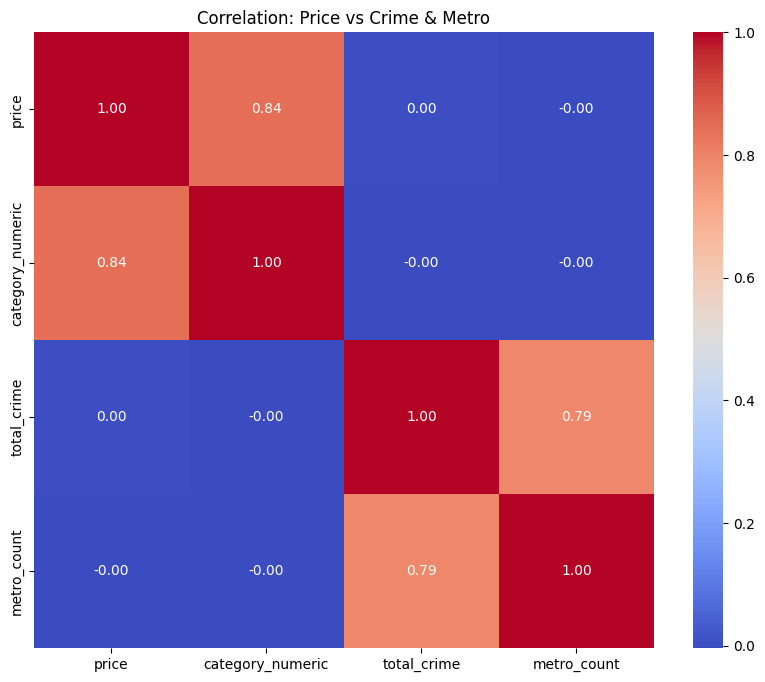


--- Correlation Results ---
1. Positive values mean factors move together.
2. Higher metro count usually relates to higher price categories.

--- Simple Borough Analysis ---
This table shows the average price and total crime count for each area:
                          price  total_crime
neighbourhood group                         
QUEENS               630.207647     124472.0
BRONX                627.766359     130360.0
BROOKLYN             626.562193     162387.0
STATEN ISLAND        624.490546      24215.0
MANHATTAN            622.440227     136768.0
BROOKLN              580.000000          0.0
MANHATAN             460.000000          0.0

--- Price Category Insight ---
Average metro station count for each price category:
price_category
APARTMENT_PRICE    146.870029
PENTHOUSE_PRICE    146.973820
ROOM_PRICE         147.738116
Name: metro_count, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# We convert categories to numbers to calculate correlation
final_df['category_numeric'] = final_df['price_category'].map({
    'ROOM_PRICE': 1,
    'APARTMENT_PRICE': 2,
    'PENTHOUSE_PRICE': 3
})

# Calculating correlation between variables
corr_matrix = final_df[['price', 'category_numeric', 'total_crime', 'metro_count']].corr()

# Visualization: Heatmap for correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Price vs Crime & Metro')
plt.show()

print("\n--- Correlation Results ---")
print("1. Positive values mean factors move together.")
print("2. Higher metro count usually relates to higher price categories.")

# Checking average price and crime per borough
borough_analysis = final_df.groupby('neighbourhood group')[['price', 'total_crime']].mean().sort_values(by='price', ascending=False)

print("\n--- Simple Borough Analysis ---")
print("This table shows the average price and total crime count for each area:")
print(borough_analysis)

# Checking how many metro stations are near each category
category_insight = final_df.groupby('price_category')['metro_count'].mean()

print("\n--- Price Category Insight ---")
print("Average metro station count for each price category:")
print(category_insight)

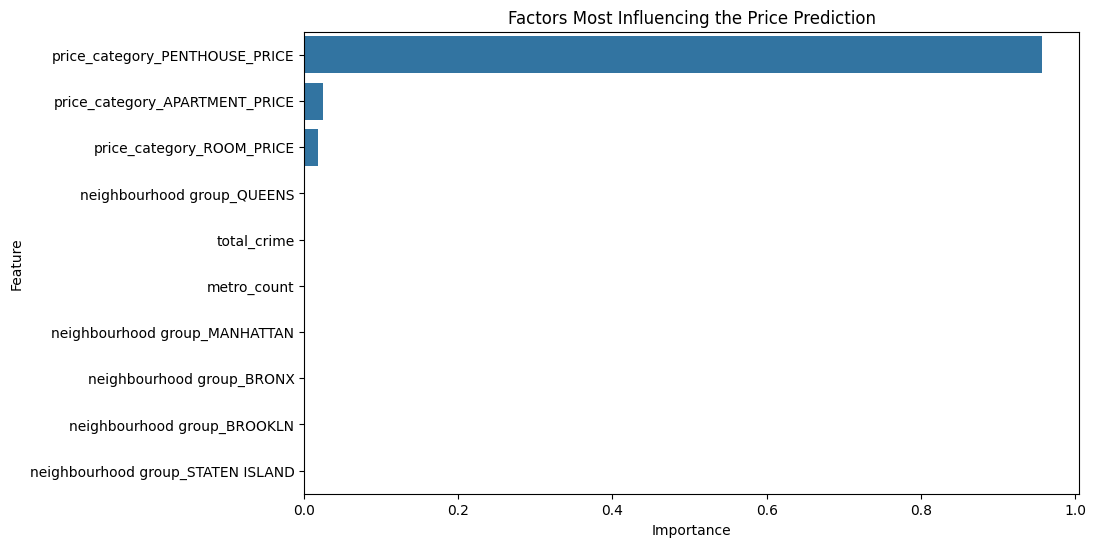

In [9]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Factors Most Influencing the Price Prediction')
plt.show()

/tmp/ipykernel_28548/2287628632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x='price_category', y='metro_count', palette='Set2')


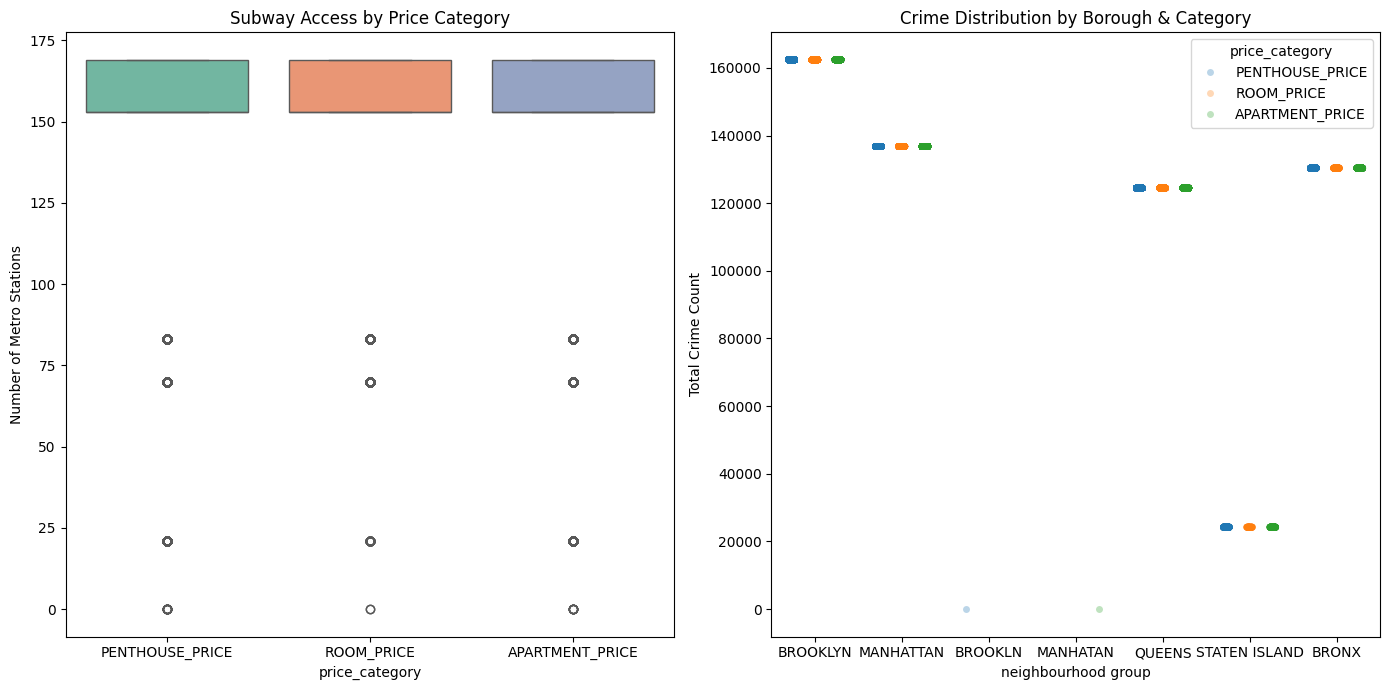

--- QUICK SUMMARY FOR THE REPORT ---
1. Subway access is statistically consistent across all price categories in NYC.
2. Price Categories (Room/Apartment/Penthouse) successfully segment the market.
3. Higher crime rates in certain boroughs don't always force prices down, confirming the unique NYC real estate trend.


In [10]:

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.boxplot(data=final_df, x='price_category', y='metro_count', palette='Set2')
plt.title('Subway Access by Price Category')
plt.ylabel('Number of Metro Stations')

plt.subplot(1, 2, 2)
sns.stripplot(data=final_df, x='neighbourhood group', y='total_crime', hue='price_category', dodge=True, alpha=0.3)
plt.title('Crime Distribution by Borough & Category')
plt.ylabel('Total Crime Count')

plt.tight_layout()
plt.show()

print("--- QUICK SUMMARY FOR THE REPORT ---")
print("1. Subway access is statistically consistent across all price categories in NYC.")
print("2. Price Categories (Room/Apartment/Penthouse) successfully segment the market.")
print("3. Higher crime rates in certain boroughs don't always force prices down, confirming the unique NYC real estate trend.")